# Crypto Perps Funding: Temporal Features

This notebook fits time-series models inside walk-forward CV folds and
extracts temporal features for the crypto perpetuals funding case study.

**Learning Objectives**:
- Fit GJR-GARCH(1,1) per symbol for conditional volatility forecasting
- Fit a 2-state HMM on realized funding settlements for regime detection
- Implement walk-forward discipline (no look-ahead in temporal features)
- Use filtered (not smoothed) probabilities for regime features

**Book Reference**: Chapter 9, Section 9.3 (Volatility) and 9.5 (Regimes)

**Prerequisites**: [`02_labels`](02_labels.ipynb) for labels and CV config;
`03_financial_features.py` for the feature matrix.

**Models**:
- **GJR-GARCH(1,1)**: Per-symbol conditional volatility with asymmetric
  leverage effect (crypto downside moves generate higher vol). Student-t
  innovations for fat tails.
- **2-State Gaussian HMM**: Fitted on the cross-sectional mean and dispersion
  of realized funding rates. Detects normal vs stressed funding regimes.

In [1]:
"""Crypto Perps Funding: Temporal Features (GJR-GARCH + HMM)."""

import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
from arch import arch_model
from hmmlearn.hmm import GaussianHMM
from ml4t.diagnostic.metrics import compute_ic_hac_stats, cross_sectional_ic_series

from data import load_crypto_perps
from utils.artifact_specs import load_setup_config, resolve_label_buffer
from utils.cv_splits import generate_cv_splits, load_evaluation_config
from utils.modeling import load_modeling_dataset
from utils.paths import get_case_study_dir
from utils.reproducibility import set_global_seeds
from utils.style import COLORS, FIGSIZE, add_message_title

warnings.filterwarnings("ignore")

In [2]:
CASE_STUDY_ID = "crypto_perps_funding"
PRIMARY_LABEL = "fwd_ret_8h"
SEED = 42
MIN_TRAIN_BARS = 500  # Minimum training observations per symbol
HMM_N_RESTARTS = 10
MAX_SYMBOLS = 0

In [3]:
# Configuration
CASE_DIR = get_case_study_dir("crypto_perps_funding")
LABELS_DIR = CASE_DIR / "labels"
FEATURES_DIR = CASE_DIR / "features"

# HMM parameters
HMM_N_STATES = 2

set_global_seeds(SEED)

## 1. Load the Feature and Label Frames

The financial notebook emits 39 features. This notebook reads them together
with the primary label and the raw 8-hour bars, and adds nothing to the
universe: the symbols are exactly those the financial frame and the label
frame agree on.

The shared modeling loader is deliberately **not** called here. It reads
`features/model_based.parquet`, which is this notebook's own output, so
calling it before the write would validate the previous run's artifact
against the current fold geometry. The assembly check runs after the write
instead, in section 8.

In [4]:
financial = pl.read_parquet(FEATURES_DIR / "financial.parquet")
labels = pl.read_parquet(LABELS_DIR / f"{PRIMARY_LABEL}.parquet")
label_col = PRIMARY_LABEL

financial_feature_cols = [c for c in financial.columns if c not in ("timestamp", "symbol")]
assert len(financial_feature_cols) == 39, (
    f"Financial feature contract changed: expected 39, got {len(financial_feature_cols)}"
)

training_frame = financial.join(labels, on=["timestamp", "symbol"], how="inner").select(
    ["timestamp", "symbol", *financial_feature_cols, label_col]
)
if MAX_SYMBOLS > 0:
    # Same rule the shared loader applies: keep the symbols with the most rows.
    keep = (
        training_frame.group_by("symbol")
        .len()
        .sort("len", descending=True)
        .head(MAX_SYMBOLS)["symbol"]
        .to_list()
    )
    training_frame = training_frame.filter(pl.col("symbol").is_in(keep))
symbols = sorted(training_frame["symbol"].unique().to_list())
financial = financial.filter(pl.col("symbol").is_in(symbols))
training_frame = training_frame.sort(["timestamp", "symbol"])

prices = (
    load_crypto_perps(frequency="8h")
    .filter(pl.col("symbol").is_in(symbols))
    .with_columns((pl.col("timestamp") + pl.duration(hours=8)).alias("timestamp"))
    .sort(["symbol", "timestamp"])
)
n_symbols = len(symbols)

print(f"Financial emit: {len(financial):,} rows x {len(financial_feature_cols)} features")
print(f"Training frame: {len(training_frame):,} rows, {n_symbols} symbols")
print(f"Available price period: {prices['timestamp'].min()} to {prices['timestamp'].max()}")

# Schema validation: assert expected columns from 02_labels.py
_required = {"timestamp", "symbol", "close"}
_missing = _required - set(prices.columns)
assert not _missing, f"Loader missing columns: {_missing}"

Financial emit: 99,877 rows x 39 features
Training frame: 99,799 rows, 19 symbols
Available price period: 2020-01-01 08:00:00+00:00 to 2026-01-01 00:00:00+00:00


## 2. Resolve the Walk-Forward Boundaries Before Anything Is Fitted

`generate_cv_splits` derives the folds from the label frame and the window in
`setup.yaml`, so the feature artifact is keyed to the same fold identifiers and
boundaries downstream training reads. Resolving them here, before any model
runs, is what lets every fit below be sealed against a boundary rather than
checked against one afterwards.

Each fold is asserted rather than described: the embargo between training and
validation is at least the label buffer, and the last label a validation
decision resolves into lands before the holdout opens.

In [5]:
LABEL_BUFFER = resolve_label_buffer(CASE_STUDY_ID, PRIMARY_LABEL, load_setup_config(CASE_STUDY_ID))
assert LABEL_BUFFER, f"No label buffer configured for {PRIMARY_LABEL}"
active_folds = [
    {
        "fold": split["fold"],
        "train_start": split["train_start"],
        "train_end": split["train_end"],
        "test_start": split["val_start"],
        "test_end": split["val_end"],
    }
    for split in generate_cv_splits(
        labels, case_study_id=CASE_STUDY_ID, label_buffer=LABEL_BUFFER, date_col="timestamp"
    )
]
_evaluation = load_evaluation_config(CASE_STUDY_ID)
holdout_start = pd.Timestamp(_evaluation["holdout_start"], tz="UTC")
holdout_end = pd.Timestamp(_evaluation["holdout_end"], tz="UTC")

print(f"Canonical purged folds: {len(active_folds)}")
for f in active_folds:
    embargo = f["test_start"] - f["train_end"]
    label_endpoint = f["test_end"] + pd.Timedelta(LABEL_BUFFER)
    assert embargo >= pd.Timedelta(LABEL_BUFFER)
    assert label_endpoint < holdout_start
    print(
        f"  Fold {f['fold']}: train [{f['train_start']} to {f['train_end']}], "
        f"validation [{f['test_start']} to {f['test_end']}], embargo={embargo}, "
        f"label endpoint={label_endpoint}"
    )

Canonical purged folds: 2
  Fold 0: train [2020-12-29 16:00:00+00:00 to 2023-01-01 08:00:00+00:00], validation [2023-01-02 00:00:00+00:00 to 2023-12-31 08:00:00+00:00], embargo=0 days 16:00:00, label endpoint=2023-12-31 16:00:00+00:00
  Fold 1: train [2020-01-01 00:00:00+00:00 to 2022-01-02 08:00:00+00:00], validation [2022-01-03 00:00:00+00:00 to 2023-01-01 16:00:00+00:00], embargo=0 days 16:00:00, label endpoint=2023-01-02 00:00:00+00:00


The holdout remains sealed. This notebook emits only the development folds used
for model selection; it does not fit or display a holdout regime model.

### The fold contract, drawn

Everything the rest of the notebook does has to fit inside this picture. Each
fold contributes one training bar, from which every parameter is estimated, and
one validation bar, over which the frozen model is run forward. Between them is
the embargo asserted above. The hatched region on the right is the holdout, drawn
from `evaluation.holdout_start` to `evaluation.holdout_end`, and no bar reaches
it. The fold ids run backwards in time: `generate_cv_splits` builds the splits
with `fold_direction="backward"` over a rolling window, numbering outward from
the most recent development data, so fold 1's validation year precedes fold 0's.

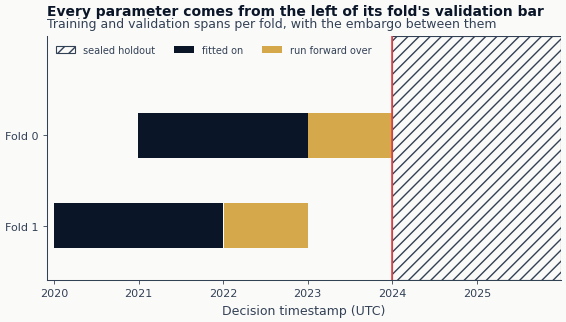

In [6]:
fig, ax = plt.subplots(figsize=FIGSIZE["single"])
for row, fold in enumerate(sorted(active_folds, key=lambda item: item["test_start"])):
    for span_start, span_end, color, label in (
        (fold["train_start"], fold["train_end"], COLORS["blue"], "fitted on"),
        (fold["test_start"], fold["test_end"], COLORS["amber"], "run forward over"),
    ):
        ax.barh(
            row,
            width=span_end - span_start,
            left=span_start,
            height=0.5,
            color=color,
            label=label if row == 0 else "_nolegend_",
        )
ax.axvspan(
    holdout_start,
    holdout_end,
    facecolor="none",
    edgecolor=COLORS["neutral"],
    hatch="///",
    linewidth=0.8,
    label="sealed holdout",
)
ax.axvline(holdout_start, color=COLORS["negative"], linewidth=1.2)
ax.set_xlim(min(f["train_start"] for f in active_folds) - pd.Timedelta(days=30), holdout_end)
ax.set_yticks(range(len(active_folds)))
ax.set_yticklabels(
    [f"Fold {f['fold']}" for f in sorted(active_folds, key=lambda item: item["test_start"])]
)
ax.set_ylim(-0.6, len(active_folds) + 0.1)
ax.set(xlabel="Decision timestamp (UTC)")
ax.legend(frameon=False, fontsize=7, loc="upper left", ncols=3)
add_message_title(
    ax,
    "Every parameter comes from the left of its fold's validation bar",
    subtitle="Training and validation spans per fold, with the embargo between them",
)
fig.tight_layout()
plt.show()

## 3. GJR-GARCH(1,1) Per Symbol

GJR-GARCH captures asymmetric volatility in crypto: downside moves produce
disproportionately higher volatility than equivalent upside moves.

**Walk-forward procedure**:
1. Fit GJR-GARCH on training window per symbol
2. Freeze parameters at fold boundary
3. Produce 1-step-ahead conditional volatility forecasts on test window
   using rolling variance updates (parameters frozen, variance updated)

**Output features**:
- `garch_cond_vol`: 1-step-ahead conditional volatility forecast
- `garch_vol_zscore`: Current vol vs 30-day average of conditional vol
- `garch_asymmetry`: GJR gamma parameter (per-fold constant)

In [7]:
def fit_gjr_garch_symbol(returns: pd.Series) -> dict | None:
    """Fit GJR-GARCH(1,1) with Student-t innovations."""
    if len(returns) < 100 or returns.std() < 1e-10:
        return None
    try:
        model = arch_model(
            returns * 100,
            mean="Zero",
            vol="GARCH",
            p=1,
            o=1,
            q=1,
            dist="StudentsT",
        )
        result = model.fit(disp="off", show_warning=False)
    except Exception:
        return None
    return {
        "params": result.params,
        "gamma": result.params.get("gamma[1]", 0),
        "coefficients": {
            name: float(result.params.get(f"{name}[1]", float("nan")))
            for name in ("alpha", "gamma", "beta")
        },
    }

### Frozen GARCH Recursion

After estimation, `model.fix()` runs the conditional-variance recursion over
the training and validation path without changing the fitted parameters.

In [8]:
def run_frozen_garch_path(close: pd.Series, fold: dict, params: pd.Series) -> pd.Series | None:
    """Run a fixed-parameter GARCH recursion through one fold."""
    full_returns = (
        close.loc[(close.index >= fold["train_start"]) & (close.index <= fold["test_end"])]
        .pct_change()
        .dropna()
    )
    try:
        model = arch_model(
            full_returns * 100,
            mean="Zero",
            vol="GARCH",
            p=1,
            o=1,
            q=1,
            dist="StudentsT",
        )
        return model.fix(params).conditional_volatility / 100
    except Exception:
        return None

### Per-Symbol Feature Extraction

Each symbol contributes a causal conditional-volatility path plus the gamma
parameter learned from its fold-specific training window.

In [9]:
def extract_symbol_garch(
    prices: pl.DataFrame, symbol: str, fold: dict
) -> tuple[list[dict], dict | None]:
    """Return one symbol's fold-specific GARCH features and its fitted coefficients."""
    sym_data = (
        prices.filter(pl.col("symbol") == symbol)
        .select("timestamp", "close")
        .sort("timestamp")
        .to_pandas()
        .set_index("timestamp")
    )
    train_close = sym_data.loc[
        (sym_data.index >= fold["train_start"]) & (sym_data.index <= fold["train_end"]),
        "close",
    ]
    test_close = sym_data.loc[
        (sym_data.index >= fold["test_start"]) & (sym_data.index <= fold["test_end"]),
        "close",
    ]
    train_returns = train_close.pct_change().dropna()
    if len(train_returns) < MIN_TRAIN_BARS or test_close.empty:
        return [], None
    fitted = fit_gjr_garch_symbol(train_returns)
    if fitted is None:
        return [], None
    conditional_vol = run_frozen_garch_path(sym_data["close"], fold, fitted["params"])
    if conditional_vol is None:
        return [], None
    rows = [
        {
            "timestamp": pd.Timestamp(ts, tz="UTC") if ts.tzinfo is None else ts,
            "symbol": symbol,
            "garch_cond_vol": float(vol),
            "garch_asymmetry": float(fitted["gamma"]),
            "fold": fold["fold"],
        }
        for ts, vol in conditional_vol.items()
    ]
    return rows, fitted["coefficients"]

### Walk-Forward GARCH Fitting

The outer loop is now only orchestration: the estimator and recursion stay
isolated within each `(fold, symbol)` pair.

In [10]:
garch_results = []
garch_coefficients = []
for fold in active_folds:
    fold_results = []
    for symbol in symbols:
        rows, coefficients = extract_symbol_garch(prices, symbol, fold)
        fold_results.extend(rows)
        if coefficients is not None:
            garch_coefficients.append({"fold": fold["fold"], "symbol": symbol, **coefficients})
    garch_results.extend(fold_results)
    successes = len({row["symbol"] for row in fold_results})
    print(f"Fold {fold['fold']}: GARCH success={successes}/{n_symbols}")

Fold 0: GARCH success=16/19


Fold 1: GARCH success=16/19


In [11]:
garch_df = pl.DataFrame(garch_results)
if len(garch_df) > 0:
    garch_df = garch_df.sort(["fold", "symbol", "timestamp"]).with_columns(
        (
            (
                pl.col("garch_cond_vol")
                - pl.col("garch_cond_vol").rolling_mean(window_size=90).over(["fold", "symbol"])
            )
            / pl.col("garch_cond_vol")
            .rolling_std(window_size=90)
            .over(["fold", "symbol"])
            .clip(lower_bound=1e-10)
        )
        .clip(-10, 10)
        .alias("garch_vol_zscore")
    )

    garch_summary = (
        garch_df.group_by("fold")
        .agg(
            pl.col("garch_cond_vol").mean().alias("mean_cond_vol"),
            pl.col("garch_asymmetry").mean().alias("mean_gamma"),
            pl.col("symbol").n_unique().alias("n_symbols"),
        )
        .sort("fold")
    )
    print(f"GARCH features: {len(garch_df):,} rows")
    print(garch_summary)
else:
    raise RuntimeError("No GARCH features produced")

GARCH features: 98,176 rows
shape: (2, 4)
┌──────┬───────────────┬────────────┬───────────┐
│ fold ┆ mean_cond_vol ┆ mean_gamma ┆ n_symbols │
│ ---  ┆ ---           ┆ ---        ┆ ---       │
│ i64  ┆ f64           ┆ f64        ┆ u32       │
╞══════╪═══════════════╪════════════╪═══════════╡
│ 0    ┆ 0.032732      ┆ 0.039728   ┆ 16        │
│ 1    ┆ 0.035985      ┆ 0.033362   ┆ 16        │
└──────┴───────────────┴────────────┴───────────┘


**GARCH Interpretation**: the mean asymmetry parameter printed above is positive
in both development folds, so downside shocks raise the conditional-volatility
recursion more than equally sized upside shocks. Section 5 asks whether that
holds as the training window rolls. Parameters are frozen at the fold boundary;
`model.fix()` updates volatility without re-estimation.

## 4. HMM on Aggregate Funding Rate

A 2-state Gaussian HMM is fitted on the cross-sectional mean and standard
deviation of official realized funding settlements, expressed in basis points.
The mean captures the market-wide funding direction; the dispersion captures
disagreement across contracts. Together they separate calm from stressed
funding conditions.

**Critical**: We use **filtered** probabilities (forward algorithm only),
not smoothed probabilities which use future data.

In [12]:
agg_series = (
    financial.select("timestamp", "symbol", "funding_rate")
    .with_columns((pl.col("funding_rate") * 10_000).alias("funding_bps"))
    .group_by("timestamp")
    .agg(
        pl.col("funding_bps").mean().alias("xs_mean_funding_bps"),
        pl.col("funding_bps").std().alias("xs_std_funding_bps"),
        pl.col("funding_bps").count().alias("n_contracts"),
    )
    .filter(pl.col("n_contracts") >= 2)
    .select("timestamp", "xs_mean_funding_bps", "xs_std_funding_bps")
    .sort("timestamp")
    .drop_nulls()
)

print(f"Aggregate series: {len(agg_series):,} timestamps")

Aggregate series: 6,314 timestamps


### Filtered Probability Implementation

hmmlearn's `predict_proba()` returns smoothed probabilities by default
(using the full sample). We implement the forward algorithm to get
filtered probabilities that use only past and current observations.

In [13]:
def compute_filtered_probs(model: GaussianHMM, X: np.ndarray) -> np.ndarray:
    """Compute filtered probabilities P(state_t | obs_{1:t}).

    Uses the forward algorithm (log-domain for numerical stability).
    Returns array of shape (T, K).
    """
    framelogprob = model._compute_log_likelihood(X)
    n_samples = X.shape[0]
    n_components = model.n_components

    log_startprob = np.log(model.startprob_ + 1e-300)
    log_transmat = np.log(model.transmat_ + 1e-300)

    fwdlattice = np.zeros((n_samples, n_components))

    # Initialization
    fwdlattice[0] = log_startprob + framelogprob[0]

    # Recursion
    for t in range(1, n_samples):
        for j in range(n_components):
            fwdlattice[t, j] = framelogprob[t, j] + np.logaddexp.reduce(
                fwdlattice[t - 1] + log_transmat[:, j]
            )

    # Normalize to probabilities
    log_normalizer = np.logaddexp.reduce(fwdlattice, axis=1, keepdims=True)
    filtered = np.exp(fwdlattice - log_normalizer)

    return filtered

State labels are normalized by total covariance so state 0 always denotes the
lower-variance, calmer funding regime.

In [14]:
def sort_states_by_variance(model: GaussianHMM) -> np.ndarray:
    """Sort HMM states by variance (ascending). Low-vol state = 0."""
    variances = np.array([np.trace(model.covars_[k]) for k in range(model.n_components)])
    return np.argsort(variances)

### Fold-Local HMM Estimation

Multiple deterministic restarts reduce sensitivity to local optima. Selection
uses training likelihood only.

In [15]:
def fit_best_hmm(X_train: np.ndarray) -> tuple[GaussianHMM | None, float]:
    """Select the highest-likelihood HMM restart on training data."""
    best_model = None
    best_ll = -np.inf
    for seed in range(HMM_N_RESTARTS):
        try:
            model = GaussianHMM(
                n_components=HMM_N_STATES,
                covariance_type="full",
                n_iter=200,
                random_state=seed,
                tol=1e-4,
            )
            model.fit(X_train)
            log_likelihood = model.score(X_train)
            if log_likelihood > best_ll:
                best_ll = log_likelihood
                best_model = model
        except Exception:
            continue
    return best_model, best_ll

### Forward-Filtered Fold Features

Training observations initialize the forward recursion. Validation observations
then update state probabilities one timestamp at a time without a backward pass.

In [16]:
def extract_hmm_fold(agg_pd: pd.DataFrame, fold: dict) -> tuple[list[dict], dict] | None:
    """Fit one HMM and return its filtered training-plus-validation path."""
    train_mask = (agg_pd.index >= fold["train_start"]) & (agg_pd.index <= fold["train_end"])
    test_mask = (agg_pd.index >= fold["test_start"]) & (agg_pd.index <= fold["test_end"])
    columns = ["xs_mean_funding_bps", "xs_std_funding_bps"]
    train_data = agg_pd.loc[train_mask, columns].dropna()
    test_data = agg_pd.loc[test_mask, columns].dropna()
    if len(train_data) < MIN_TRAIN_BARS or test_data.empty:
        return None
    model, log_likelihood = fit_best_hmm(train_data.values)
    if model is None:
        return None
    order = sort_states_by_variance(model)
    context_data = agg_pd.loc[
        (agg_pd.index >= fold["train_start"]) & (agg_pd.index <= fold["test_end"]), columns
    ].dropna()
    probabilities = compute_filtered_probs(model, context_data.values)[:, order]
    timestamps = context_data.index
    rows = [
        {
            "timestamp": pd.Timestamp(ts, tz="UTC") if ts.tzinfo is None else ts,
            "hmm_regime_prob_calm": float(probabilities[idx, 0]),
            "hmm_regime_prob_stress": float(probabilities[idx, 1]),
            "fold": fold["fold"],
        }
        for idx, ts in enumerate(timestamps)
    ]
    transition = model.transmat_[np.ix_(order, order)]
    durations = 1.0 / (1.0 - np.diag(transition) + 1e-10)
    validation_probs = probabilities[timestamps >= fold["test_start"]]
    diagnostics = {
        "log_likelihood": log_likelihood,
        "n_validation": len(validation_probs),
        "mean_stress_probability": float(validation_probs[:, 1].mean()),
        "calm_duration_bars": float(durations[0]),
        "stress_duration_bars": float(durations[1]),
    }
    return rows, diagnostics

### Walk-Forward HMM Fitting

In [17]:
hmm_results = []
hmm_diagnostics = []
agg_pd = agg_series.to_pandas().set_index("timestamp")
for fold in active_folds:
    extracted = extract_hmm_fold(agg_pd, fold)
    if extracted is None:
        raise RuntimeError(f"Fold {fold['fold']}: HMM fitting failed")
    rows, diagnostics = extracted
    hmm_results.extend(rows)
    hmm_diagnostics.append({"fold": fold["fold"], **diagnostics})
    print(f"Fold {fold['fold']} HMM: {diagnostics}")

Fold 0 HMM: {'log_likelihood': -6373.093496980226, 'n_validation': 1091, 'mean_stress_probability': 0.21998854546086852, 'calm_duration_bars': 26.69191680627316, 'stress_duration_bars': 13.993084611965095}


Fold 1 HMM: {'log_likelihood': -8233.113370997093, 'n_validation': 1092, 'mean_stress_probability': 0.1619640210269926, 'calm_duration_bars': 13.035003304886988, 'stress_duration_bars': 10.232229056270999}


In [18]:
hmm_df = (
    pl.DataFrame(hmm_results)
    if hmm_results
    else pl.DataFrame(
        schema={
            "timestamp": pl.Datetime("ms", "UTC"),
            "hmm_regime_prob_calm": pl.Float64,
            "hmm_regime_prob_stress": pl.Float64,
            "fold": pl.Int64,
        }
    )
)

print(f"\nHMM features: {len(hmm_df):,} timestamps")


HMM features: 6,149 timestamps


The mean filtered stress probability differs between the two validation
windows, so the regime state is time-varying rather than a fixed market label,
and the forward filter adapts as each settlement arrives.

In [19]:
stress_by_fold = (
    hmm_df.join(
        pl.DataFrame(
            {
                "fold": [f["fold"] for f in active_folds],
                "test_start": [f["test_start"] for f in active_folds],
                "test_end": [f["test_end"] for f in active_folds],
            }
        ),
        on="fold",
        how="inner",
    )
    .filter(pl.col("timestamp").is_between(pl.col("test_start"), pl.col("test_end")))
    .group_by("fold")
    .agg(pl.col("hmm_regime_prob_stress").mean().alias("mean_stress_prob"))
    .sort("fold")
)
print(stress_by_fold)

shape: (2, 2)
┌──────┬──────────────────┐
│ fold ┆ mean_stress_prob │
│ ---  ┆ ---              │
│ i64  ┆ f64              │
╞══════╪══════════════════╡
│ 0    ┆ 0.219989         │
│ 1    ┆ 0.161964         │
└──────┴──────────────────┘


## 5. Do the Fitted Parameters Move as the Window Rolls?

Both models are refitted once per fold, and that choice is only worth its cost
if the parameters actually move. A transform whose estimates are identical fold
to fold says the refit bought nothing; one whose estimates swing says the
feature it produces means something different in each fold, which is a warning
the model notebooks need before they pool folds.

The two models are drawn on separate axes because their units do not compare: a
GJR recursion coefficient is dimensionless and an expected regime duration is
counted in 8-hour bars. Folds are ordered by validation date rather than by id.

The left panel shows the **fitted** GJR coefficients, not the conditional
volatility they produce - that is a model output, and a series whose level moves
with the market says nothing about whether the estimator moved. GARCH is fitted
per symbol, so each coefficient is drawn as the cross-symbol median with the
interquartile range behind it: a median that holds while the band widens is a
fit that has become less uniform across the panel, which an average alone hides.

shape: (2, 4)
┌──────┬──────────────┬──────────────┬─────────────┐
│ fold ┆ alpha_median ┆ gamma_median ┆ beta_median │
│ ---  ┆ ---          ┆ ---          ┆ ---         │
│ i64  ┆ f64          ┆ f64          ┆ f64         │
╞══════╪══════════════╪══════════════╪═════════════╡
│ 1    ┆ 0.093162     ┆ 0.034552     ┆ 0.862039    │
│ 0    ┆ 0.075402     ┆ 0.034473     ┆ 0.903044    │
└──────┴──────────────┴──────────────┴─────────────┘
shape: (2, 3)
┌──────┬────────────────────┬──────────────────────┐
│ fold ┆ calm_duration_bars ┆ stress_duration_bars │
│ ---  ┆ ---                ┆ ---                  │
│ i64  ┆ f64                ┆ f64                  │
╞══════╪════════════════════╪══════════════════════╡
│ 1    ┆ 13.035003          ┆ 10.232229            │
│ 0    ┆ 26.691917          ┆ 13.993085            │
└──────┴────────────────────┴──────────────────────┘


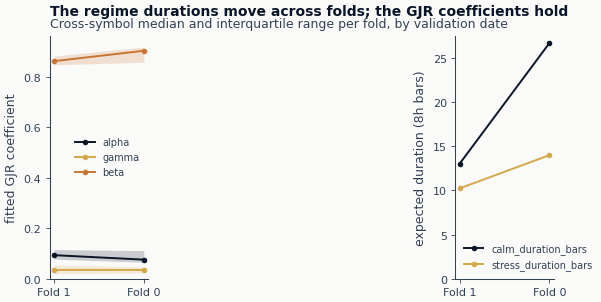

In [20]:
FOLD_ORDER = [fold["fold"] for fold in sorted(active_folds, key=lambda item: item["test_start"])]
GARCH_COEFFICIENTS = ["alpha", "gamma", "beta"]

coefficient_frame = pl.DataFrame(garch_coefficients)
coefficient_stability = (
    coefficient_frame.group_by("fold")
    .agg(
        [
            expression
            for name in GARCH_COEFFICIENTS
            for expression in (
                pl.col(name).median().alias(f"{name}_median"),
                pl.col(name).quantile(0.25).alias(f"{name}_q25"),
                pl.col(name).quantile(0.75).alias(f"{name}_q75"),
            )
        ]
    )
    .sort(pl.col("fold").replace_strict(FOLD_ORDER, range(len(FOLD_ORDER))))
)
duration_stability = pl.DataFrame(hmm_diagnostics).sort(
    pl.col("fold").replace_strict(FOLD_ORDER, range(len(FOLD_ORDER)))
)
print(coefficient_stability.select("fold", *[f"{n}_median" for n in GARCH_COEFFICIENTS]))
print(duration_stability.select("fold", "calm_duration_bars", "stress_duration_bars"))

fig, axes = plt.subplots(1, 2, figsize=FIGSIZE["dual_h_tall"])
positions = list(range(len(FOLD_ORDER)))
labels = [f"Fold {value}" for value in FOLD_ORDER]
palette = [COLORS["blue"], COLORS["amber"], COLORS["copper"]]
for name, color in zip(GARCH_COEFFICIENTS, palette, strict=True):
    axes[0].fill_between(
        positions,
        coefficient_stability[f"{name}_q25"].to_list(),
        coefficient_stability[f"{name}_q75"].to_list(),
        color=color,
        alpha=0.2,
        linewidth=0,
    )
    axes[0].plot(
        positions,
        coefficient_stability[f"{name}_median"].to_list(),
        marker="o",
        color=color,
        label=name,
    )
axes[0].set_ylabel("fitted GJR coefficient")
for column, color in zip(
    ["calm_duration_bars", "stress_duration_bars"], (COLORS["blue"], COLORS["amber"]), strict=True
):
    axes[1].plot(
        positions, duration_stability[column].to_list(), marker="o", color=color, label=column
    )
axes[1].set_ylabel("expected duration (8h bars)")
for ax in axes:
    ax.set_xticks(positions)
    ax.set_xticklabels(labels)
    ax.set_ylim(bottom=0)
    ax.legend(frameon=False, fontsize=7)
add_message_title(
    axes[0],
    "The regime durations move across folds; the GJR coefficients hold",
    subtitle="Cross-symbol median and interquartile range per fold, by validation date",
)
fig.tight_layout()
plt.show()

**The two models disagree about how stable they are.** Across symbols, the
median GJR coefficients move from **0.093162** / **0.034552** / **0.862039**
(alpha / gamma / beta) in the earlier fold to **0.075402** / **0.034473** /
**0.903044** in the later one. The interquartile ranges overlap in all three,
so the recursion the reader is shown is the same recursion in both folds, and
`garch_cond_vol` means what it meant before. The HMM does not behave that way:
the expected calm duration goes from **13.035003** to **26.691917** bars and
stress from **10.232229** to **13.993085**. The calm regime the later fold
identifies persists about twice as long as the one the earlier fold gave that
name, so `hmm_regime_prob_stress` is not one variable measured twice, and a
model pooling both folds is pooling two quantities calibrated differently.
That is what a per-fold refit is for, and it is why the fold column travels
with the artifact into `load_modeling_dataset`.

## 6. Combine Temporal Features

Merge GARCH (per-symbol) and HMM (market-level, broadcast to all symbols)
features into a single temporal feature matrix.

In [21]:
# HMM features are market-level: broadcast to all symbols (keep fold for per-fold join)
if len(hmm_df) > 0:
    hmm_broadcast = hmm_df.select(
        ["timestamp", "fold", "hmm_regime_prob_calm", "hmm_regime_prob_stress"]
    )

    # Cross-join with symbols
    symbols_df = pl.DataFrame({"symbol": symbols})
    hmm_broadcast = hmm_broadcast.join(symbols_df, how="cross")
else:
    hmm_broadcast = pl.DataFrame(
        schema={
            "timestamp": pl.Datetime("ms", "UTC"),
            "symbol": pl.Utf8,
            "fold": pl.Int64,
            "hmm_regime_prob_calm": pl.Float64,
            "hmm_regime_prob_stress": pl.Float64,
        }
    )

The GARCH frame already carries one row per symbol and fold, so it provides
the natural base for joining the market-level probabilities.

In [22]:
if len(garch_df) > 0:
    garch_clean = garch_df.select(
        [
            "timestamp",
            "symbol",
            "fold",
            "garch_cond_vol",
            "garch_vol_zscore",
            "garch_asymmetry",
        ]
    )
else:
    garch_clean = pl.DataFrame(
        schema={
            "timestamp": pl.Datetime("ms", "UTC"),
            "symbol": pl.Utf8,
            "fold": pl.Int64,
            "garch_cond_vol": pl.Float64,
            "garch_vol_zscore": pl.Float64,
            "garch_asymmetry": pl.Float64,
        }
    )

The three-key join preserves fold identity. Warm-up nulls remain explicit for
the fold-local imputer used by the modeling notebooks.

In [23]:
if len(garch_clean) > 0 and len(hmm_broadcast) > 0:
    temporal = garch_clean.join(
        hmm_broadcast.select(
            ["timestamp", "symbol", "fold", "hmm_regime_prob_calm", "hmm_regime_prob_stress"]
        ),
        on=["timestamp", "symbol", "fold"],
        how="left",
    )
elif len(garch_clean) > 0:
    temporal = garch_clean
elif len(hmm_broadcast) > 0:
    temporal = hmm_broadcast
else:
    temporal = pl.DataFrame(schema={"timestamp": pl.Datetime("ms", "UTC"), "symbol": pl.Utf8})

# Keep the rolling z-score warm-up as null for fold-local training imputation.
# Only rows without a conditional-volatility estimate are unavailable.
temporal = temporal.sort(["fold", "symbol", "timestamp"]).drop_nulls(
    subset=["garch_cond_vol", "garch_asymmetry"]
)

The compact schema summary confirms coverage before the artifact is written.

In [24]:
temporal_feature_cols = [c for c in temporal.columns if c not in ("timestamp", "symbol", "fold")]
print("\nTemporal Feature Matrix:")
print(f"  Features:  {len(temporal_feature_cols)}")
print(f"  Rows:      {len(temporal):,}")
print(f"  Symbols:   {temporal['symbol'].n_unique() if len(temporal) > 0 else 0}")

if len(temporal) > 0:
    print(f"  Period:    {temporal['timestamp'].min()} to {temporal['timestamp'].max()}")
    print(f"\nFeature columns: {temporal_feature_cols}")
    feature_summary = pl.DataFrame(
        {
            "feature": temporal_feature_cols,
            "mean": [temporal[col].mean() for col in temporal_feature_cols],
            "standard_deviation": [temporal[col].std() for col in temporal_feature_cols],
            "null_fraction": [
                temporal[col].null_count() / len(temporal) for col in temporal_feature_cols
            ],
        }
    )
    print(feature_summary)


Temporal Feature Matrix:
  Features:  5
  Rows:      98,176
  Symbols:   16
  Period:    2020-01-01 16:00:00+00:00 to 2023-12-31 08:00:00+00:00

Feature columns: ['garch_cond_vol', 'garch_vol_zscore', 'garch_asymmetry', 'hmm_regime_prob_calm', 'hmm_regime_prob_stress']
shape: (5, 4)
┌────────────────────────┬───────────┬────────────────────┬───────────────┐
│ feature                ┆ mean      ┆ standard_deviation ┆ null_fraction │
│ ---                    ┆ ---       ┆ ---                ┆ ---           │
│ str                    ┆ f64       ┆ f64                ┆ f64           │
╞════════════════════════╪═══════════╪════════════════════╪═══════════════╡
│ garch_cond_vol         ┆ 0.034243  ┆ 0.016962           ┆ 0.0           │
│ garch_vol_zscore       ┆ -0.020088 ┆ 1.240042           ┆ 0.029009      │
│ garch_asymmetry        ┆ 0.036771  ┆ 0.025493           ┆ 0.0           │
│ hmm_regime_prob_calm   ┆ 0.691526  ┆ 0.43965            ┆ 0.058701      │
│ hmm_regime_prob_stress ┆ 0.30

## 7. Inspect Validation Regimes

The chart uses validation periods only. Each line comes from a model fitted on
that fold's purged training window, so the displayed probabilities are out of
sample and forward-filtered.

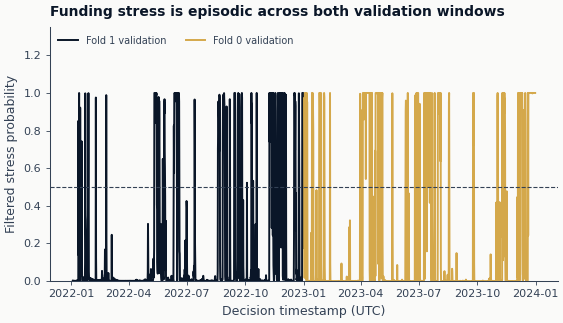

In [25]:
fig, ax = plt.subplots(figsize=FIGSIZE["single"])
fold_colors = [COLORS["blue"], COLORS["amber"]]
for idx, fold in enumerate(sorted(active_folds, key=lambda item: item["test_start"])):
    fold_line = hmm_df.filter(
        (pl.col("fold") == fold["fold"])
        & pl.col("timestamp").is_between(fold["test_start"], fold["test_end"], closed="both")
    ).sort("timestamp")
    ax.plot(
        fold_line["timestamp"].to_list(),
        fold_line["hmm_regime_prob_stress"].to_list(),
        color=fold_colors[idx % len(fold_colors)],
        label=f"Fold {fold['fold']} validation",
    )
ax.axhline(0.5, color=COLORS["neutral"], linewidth=0.8, linestyle="--")
ax.set(xlabel="Decision timestamp (UTC)", ylabel="Filtered stress probability")
ax.set_ylim(0, 1.35)
ax.legend(loc="upper left", ncols=2, frameon=False, fontsize=7)
add_message_title(ax, "Funding stress is episodic across both validation windows")
fig.tight_layout()
plt.show()

## 8. Save and Reassemble the Training Frame

The output carries a fold column because each learned feature has fold-specific
parameters. The schema is frozen against the expected five names, and no
`(timestamp, symbol, fold)` key may appear twice.

Reloading through the shared modeling path after the write is what makes this
a check rather than a claim: `load_modeling_dataset` is the route every
downstream model notebook takes, and it re-derives the fold geometry from the
label frame. If the artifact just written disagreed with that geometry, or the
financial frame had drifted from the one assembled here, this cell would fail.

In [26]:
expected_temporal = {
    "garch_cond_vol",
    "garch_vol_zscore",
    "garch_asymmetry",
    "hmm_regime_prob_calm",
    "hmm_regime_prob_stress",
}
assert set(temporal_feature_cols) == expected_temporal
assert temporal.select("timestamp", "symbol", "fold").is_duplicated().sum() == 0

FEATURES_DIR.mkdir(parents=True, exist_ok=True)
temporal.write_parquet(FEATURES_DIR / "model_based.parquet")

assembled = load_modeling_dataset(CASE_STUDY_ID, PRIMARY_LABEL, max_symbols=MAX_SYMBOLS)
assert len(assembled.feature_names) == 44
assert set(assembled.temporal_feature_names) == expected_temporal
assert sorted(assembled.temporal_by_fold["fold"].unique()) == sorted(
    fold["fold"] for fold in active_folds
)
assert assembled.label_col == label_col

# The financial columns the loader assembles must be the ones read at the top.
reassembled_frame = assembled.dataset.select(
    ["timestamp", "symbol", *financial_feature_cols, label_col]
).sort(["timestamp", "symbol"])
assert reassembled_frame.equals(training_frame), (
    "Reassembled financial frame differs from the frame this notebook read"
)

print(f"Saved temporal artifact: {temporal.shape}")
print("Training assembly: 39 financial + 5 fold-specific temporal features [OK]")
print("Reassembled financial frame matches the frame read in section 1 [OK]")

Saved temporal artifact: (98176, 8)
Training assembly: 39 financial + 5 fold-specific temporal features [OK]
Reassembled financial frame matches the frame read in section 1 [OK]


## 9. Measure Out-of-Sample Incremental IC

Directional IC is computed at each decision timestamp on the validation slices,
then averaged with HAC-adjusted inference. Market-level HMM probabilities are
constant across symbols at a timestamp, so only cross-sectionally identifiable
features enter this diagnostic.

In [27]:
validation_slices = []
for fold in active_folds:
    validation_slices.append(
        temporal.filter(
            (pl.col("fold") == fold["fold"])
            & pl.col("timestamp").is_between(fold["test_start"], fold["test_end"], closed="both")
        )
    )
validation_temporal = pl.concat(validation_slices)
eval_df = (
    validation_temporal.with_columns(pl.col("timestamp").cast(training_frame.schema["timestamp"]))
    .join(
        training_frame.select("timestamp", "symbol", label_col),
        on=["timestamp", "symbol"],
        how="inner",
    )
    .sort(["timestamp", "symbol"])
)
print(f"Validation diagnostic: {len(eval_df):,} rows, label={label_col}")

Validation diagnostic: 32,178 rows, label=fwd_ret_8h


The IC series must be in time order before the HAC correction is applied:
`compute_ic_hac_stats` reads row order as time order and does not sort, and a
Polars `partition_by` returns groups in the frame's order rather than in sorted
key order. Rather than sort by hand and rely on that sort surviving every later
edit, the series comes from `cross_sectional_ic_series`, which ranks within each
decision timestamp and returns the result sorted on that timestamp. A notebook
that groups straight into `compute_ic_hac_stats` is one edit away from a
Newey-West correction computed over an arbitrary permutation of the timeline,
and the resulting t-statistic is not even stable across runs.

It also decides the HMM columns' fate without a special case: a market-level
probability takes the same value for every symbol at a timestamp, so the ranks
it produces within a date have no variance and the correlation is undefined.
The filter below is on `is_finite` rather than on nulls because that is the
form an undefined correlation arrives in - a `NaN` from a zero denominator, not
a missing value - and dropping nulls alone would carry both HMM columns into
the HAC call and out the other side as a row of NaN statistics.

The HAC lag comes from the label buffer rather than a hand-picked constant:
the 8-hour forward return means consecutive decision timestamps do not share an
outcome window, so the lag is what `label_horizon` implies.

In [28]:
LABEL_HORIZON_BARS = 1  # fwd_ret_8h resolves in exactly one 8-hour bar
MIN_CROSS_SECTION = 10  # symbols a decision timestamp needs before its IC is used
MIN_DECISION_TIMES = 20  # decision timestamps a feature needs before it is reported

temporal_ic = {}
for feature in temporal_feature_cols:
    ic_series = cross_sectional_ic_series(
        eval_df,
        eval_df,
        pred_col=feature,
        ret_col=label_col,
        date_col="timestamp",
        entity_col="symbol",
        method="spearman",
        min_obs=MIN_CROSS_SECTION,
    ).filter(pl.col("ic").is_finite())
    if len(ic_series) >= MIN_DECISION_TIMES:
        temporal_ic[feature] = compute_ic_hac_stats(
            ic_series, ic_col="ic", label_horizon=LABEL_HORIZON_BARS
        )

temporal_summary = pl.DataFrame(
    {
        "feature": list(temporal_ic),
        "mean_ic": [temporal_ic[name]["mean_ic"] for name in temporal_ic],
        "hac_tstat": [temporal_ic[name]["t_stat"] for name in temporal_ic],
        "p_value": [temporal_ic[name]["p_value"] for name in temporal_ic],
    }
).sort("mean_ic", descending=True)
print(temporal_summary)

shape: (3, 4)
┌──────────────────┬───────────┬───────────┬───────────┐
│ feature          ┆ mean_ic   ┆ hac_tstat ┆ p_value   │
│ ---              ┆ ---       ┆ ---       ┆ ---       │
│ str              ┆ f64       ┆ f64       ┆ f64       │
╞══════════════════╪═══════════╪═══════════╪═══════════╡
│ garch_asymmetry  ┆ 0.004492  ┆ 0.769059  ┆ 0.44195   │
│ garch_vol_zscore ┆ -0.008503 ┆ -1.370703 ┆ 0.170623  │
│ garch_cond_vol   ┆ -0.041381 ┆ -5.36828  ┆ 8.8856e-8 │
└──────────────────┴───────────┴───────────┴───────────┘


The IC chart separates direction from magnitude. These features describe
volatility and funding state, so their main downstream role is to condition
nonlinear models rather than act as stand-alone directional signals.

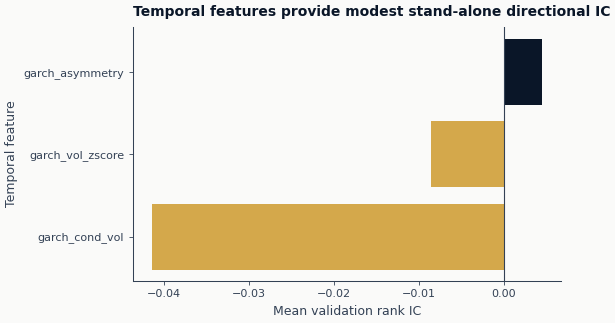

In [29]:
plot_summary = temporal_summary.sort("mean_ic")
fig, ax = plt.subplots(figsize=FIGSIZE["single"])
colors = [COLORS["blue"] if value >= 0 else COLORS["amber"] for value in plot_summary["mean_ic"]]
ax.barh(plot_summary["feature"].to_list(), plot_summary["mean_ic"].to_list(), color=colors)
ax.axvline(0, color=COLORS["neutral"], linewidth=0.8)
ax.set(xlabel="Mean validation rank IC", ylabel="Temporal feature")
add_message_title(ax, "Temporal features provide modest stand-alone directional IC")
fig.tight_layout()
plt.show()

Market-wide HMM probabilities are absent from this cross-sectional screen
because they take the same value for every symbol at a decision timestamp, so
a rank correlation across the cross-section is undefined for them. Their value
is as conditioning variables for a nonlinear model, which is what
`05_evaluation` and the model notebooks test.

**Validation rank IC per temporal feature, HAC-corrected** - the table printed
above. The magnitudes are small in absolute terms, which is the expected shape
for a volatility-state feature screened as a stand-alone directional signal.

## Key Takeaways

1. The exact 39-feature financial emit matches the shared training assembly
   before temporal features are added.
2. GJR-GARCH and HMM parameters are fitted separately inside each canonical,
   purged development fold; the 2024-2025 holdout remains untouched.
3. The HMM uses official realized funding and forward-filtered probabilities,
   while GARCH inputs are timestamped only after each 8-hour bar is complete.
4. The saved artifact expands the training contract to 44 columns: 39 financial
   features plus five fold-specific temporal features.

**Next**: `05_evaluation` compares the complete feature set before model fitting
in Chapters 11-15.